In [1]:
import gymnasium as gym
import gymnasium_jsbsim  # noqa: F401
from stable_baselines3 import DDPG
from stable_baselines3.common.vec_env import SubprocVecEnv, DummyVecEnv

In [2]:
def make_env(i):
    def _init():
        # for each subprocess
        import gymnasium_jsbsim
        # create an environment
        env = gym.make("JSBSim-HeadingControlTask-Cessna172P-Shaping.STANDARD-NoFG-v0")
        # create a fixed seed env
        # initial Heading Control Task ignores seed and sets the observation env
        # TODO create a new task that incorporates seed and optionally normalizes observation space
        obs, info = env.reset(seed=42+i)
        print(obs)
        return env
    return _init
envs = SubprocVecEnv([make_env(i) for i in range(5)])



     JSBSim Flight Dynamics Model v1.2.4 Feb  7 2026 11:12:49
            [JSBSim-ML v2.0]

JSBSim startup beginning ...

[ 5.00000000e+03  1.21430643e-17  1.50920942e-16  2.02536000e+02
  4.44089210e-15 -5.32907052e-15  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00 -3.72529030e-09  1.25629209e-15  0.00000000e+00
  2.99000000e+02]


     JSBSim Flight Dynamics Model v1.2.4 Feb  7 2026 11:12:49
            [JSBSim-ML v2.0]

JSBSim startup beginning ...

[ 5.00000000e+03  1.21430643e-17  1.50920942e-16  2.02536000e+02
  4.44089210e-15 -5.32907052e-15  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00 -3.72529030e-09  1.25629209e-15  0.00000000e+00
  2.99000000e+02]


     JSBSim Flight Dynamics Model v1.2.4 Feb  7 2026 11:12:49
            [JSBSim-ML v2.0]

JSBSim startup beginning ...

[ 5.00000000e+03  1.21430643e-17  1.50920942e-16  2.02536000e+02
  4.440

In [ ]:
# train the model
model = DDPG("MlpPolicy", envs, verbose=1, tensorboard_log="../logs/ddpg", seed=42, device='cuda')
model.learn(total_timesteps=100_000, log_interval=10)
model.save("../models/ddpg_no_tuning_100_000")

Using cuda device
Logging to ../logs/ddpg/DDPG_1
---------------------------------
| time/              |          |
|    episodes        | 10       |
|    fps             | 1699     |
|    time_elapsed    | 0        |
|    total_timesteps | 800      |
| train/             |          |
|    actor_loss      | -116     |
|    critic_loss     | 36.2     |
|    learning_rate   | 0.001    |
|    n_updates       | 139      |
---------------------------------
---------------------------------
| time/              |          |
|    episodes        | 20       |
|    fps             | 1609     |
|    time_elapsed    | 0        |
|    total_timesteps | 1410     |
| train/             |          |
|    actor_loss      | -111     |
|    critic_loss     | 6        |
|    learning_rate   | 0.001    |
|    n_updates       | 261      |
---------------------------------
---------------------------------
| time/              |          |
|    episodes        | 30       |
|    fps             | 1592     |

C:\Users\danie\AppData\Local\Temp\ipykernel_11232\2481496732.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


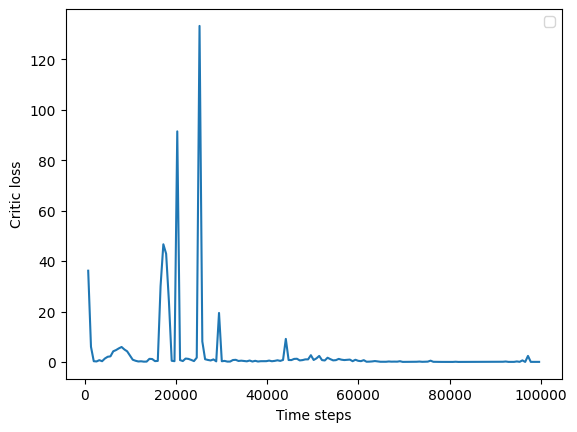

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../graphs/DDPG_1_critic.csv")
plt.plot(df['Step'], df['Value'])
plt.ylabel('Critic loss')
plt.xlabel('Time steps')
plt.legend()
plt.show()

C:\Users\danie\AppData\Local\Temp\ipykernel_11232\3538850662.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


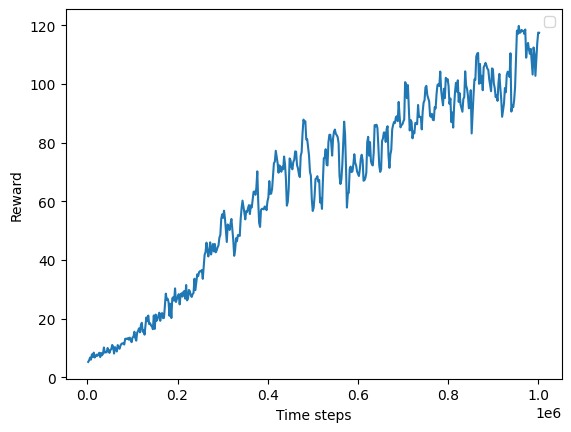

In [4]:
df = pd.read_csv("../graphs/DDPG_1_actor.csv")
plt.plot(df['Step'], df['Value'])
plt.ylabel('Actor loss')
plt.xlabel('Time steps')
plt.legend()
plt.show()

In [34]:
# tune the learning rate
for i in [3e-7, 1e-7, 3e-6, 1e-6, 3e-5, 1e-4, 3e-4, 1e-3]:
    model = DDPG("MlpPolicy", envs, verbose=1, tensorboard_log="../logs/ddpg", seed=42, device='cuda', learning_rate=i)
    model.learn(total_timesteps=100_000, log_interval=10)
    model.save(f"../models/ddpg_tuning_lr{i}_100_000")

Using cuda device
Logging to ../logs/ddpg/DDPG_2
---------------------------------
| time/              |          |
|    episodes        | 10       |
|    fps             | 1618     |
|    time_elapsed    | 0        |
|    total_timesteps | 800      |
| train/             |          |
|    actor_loss      | -132     |
|    critic_loss     | 122      |
|    learning_rate   | 3e-07    |
|    n_updates       | 139      |
---------------------------------
---------------------------------
| time/              |          |
|    episodes        | 20       |
|    fps             | 1596     |
|    time_elapsed    | 0        |
|    total_timesteps | 1410     |
| train/             |          |
|    actor_loss      | -127     |
|    critic_loss     | 173      |
|    learning_rate   | 3e-07    |
|    n_updates       | 261      |
---------------------------------
---------------------------------
| time/              |          |
|    episodes        | 30       |
|    fps             | 1516     |

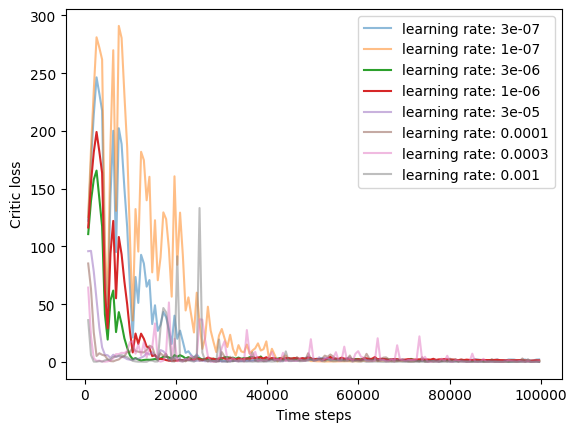

In [39]:
i = 2
for lr in [3e-7, 1e-7, 3e-6, 1e-6, 3e-5, 1e-4, 3e-4, 1e-3]:
    df = pd.read_csv(f"../graphs/DDPG_{i}_critic.csv")
    if i == 4 or i == 5:
        a = 1.0
    else:
        a = 0.5
    plt.plot(df['Step'], df['Value'], label=f"learning rate: {lr}", alpha=a)
    i+=1
plt.ylabel('Critic loss')
plt.xlabel('Time steps')
plt.legend()
plt.show()

In [ ]:
from stable_baselines3.common.noise import NormalActionNoise

model = DDPG("MlpPolicy", envs, verbose=1, tensorboard_log="../logs/ddpg", seed=42, device='cuda', learning_rate=3e-06, action_noise=NormalActionNoise([0, 0, 0], [0.5, 0.5, 0.5]))
model.learn(total_timesteps=100_000, log_interval=10)
model.save(f"../models/ddpg_lr3e-06_100_000")

Using cuda device
Logging to ../logs/ddpg/DDPG_10
---------------------------------
| time/              |          |
|    episodes        | 10       |
|    fps             | 347      |
|    time_elapsed    | 2        |
|    total_timesteps | 759      |
| train/             |          |
|    actor_loss      | -121     |
|    critic_loss     | 175      |
|    learning_rate   | 3e-06    |
|    n_updates       | 658      |
---------------------------------
---------------------------------
| time/              |          |
|    episodes        | 20       |
|    fps             | 347      |
|    time_elapsed    | 3        |
|    total_timesteps | 1387     |
| train/             |          |
|    actor_loss      | -112     |
|    critic_loss     | 41       |
|    learning_rate   | 3e-06    |
|    n_updates       | 1286     |
---------------------------------
---------------------------------
| time/              |          |
|    episodes        | 30       |
|    fps             | 343      

In [18]:
from stable_baselines3.common.noise import NormalActionNoise
from stable_baselines3.common.utils import LinearSchedule

model = DDPG("MlpPolicy", envs, verbose=1, tensorboard_log="../logs/ddpg", seed=42, device='cuda', learning_rate=LinearSchedule(start=3e-3, end=3e-6, end_fraction=1.0), action_noise=NormalActionNoise([0, 0, 0], [0.5, 0.5, 0.5]))
model.learn(total_timesteps=100_000, log_interval=10)
model.save(f"../models/ddpg_linear_lr_100_000")

Using cuda device
Logging to ../logs/ddpg/DDPG_11
---------------------------------
| time/              |          |
|    episodes        | 10       |
|    fps             | 402      |
|    time_elapsed    | 1        |
|    total_timesteps | 759      |
| train/             |          |
|    actor_loss      | -15.2    |
|    critic_loss     | 0.0553   |
|    learning_rate   | 0.00298  |
|    n_updates       | 658      |
---------------------------------
---------------------------------
| time/              |          |
|    episodes        | 20       |
|    fps             | 371      |
|    time_elapsed    | 3        |
|    total_timesteps | 1387     |
| train/             |          |
|    actor_loss      | -15.1    |
|    critic_loss     | 0.117    |
|    learning_rate   | 0.00296  |
|    n_updates       | 1286     |
---------------------------------
---------------------------------
| time/              |          |
|    episodes        | 30       |
|    fps             | 363      

In [24]:
from stable_baselines3.common.noise import NormalActionNoise
from stable_baselines3.common.utils import LinearSchedule

for i in [0.02, 0.05, 0.1, 0.2, 0.5]:
    model = DDPG("MlpPolicy", envs, verbose=1, tensorboard_log="../logs/ddpg", seed=42, device='cuda', learning_rate=LinearSchedule(start=3e-3, end=3e-6, end_fraction=1.0), action_noise=NormalActionNoise([0, 0, 0], [i, i, i]))
    model.learn(total_timesteps=100_000, log_interval=10)
    model.save(f"../models/ddpg_noise{i}_100_000")

Using cuda device
Logging to ../logs/ddpg/DDPG_12
---------------------------------
| time/              |          |
|    episodes        | 10       |
|    fps             | 1535     |
|    time_elapsed    | 0        |
|    total_timesteps | 810      |
| train/             |          |
|    actor_loss      | -134     |
|    critic_loss     | 4.09     |
|    learning_rate   | 0.00298  |
|    n_updates       | 141      |
---------------------------------
---------------------------------
| time/              |          |
|    episodes        | 20       |
|    fps             | 1490     |
|    time_elapsed    | 0        |
|    total_timesteps | 1430     |
| train/             |          |
|    actor_loss      | -120     |
|    critic_loss     | 34.7     |
|    learning_rate   | 0.00296  |
|    n_updates       | 265      |
---------------------------------
---------------------------------
| time/              |          |
|    episodes        | 30       |
|    fps             | 1442     

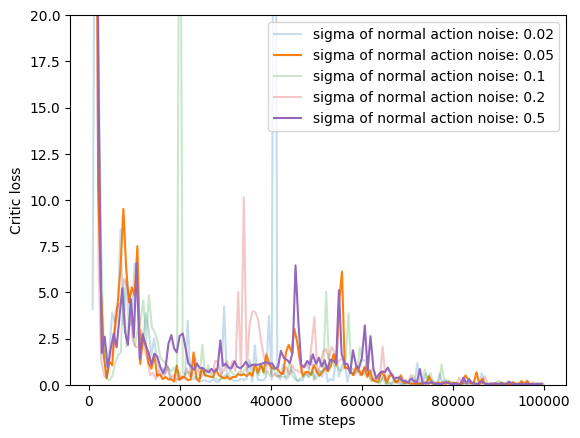

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

i = 12
for lr in [0.02, 0.05, 0.1, 0.2, 0.5]:
    df = pd.read_csv(f"../graphs/DDPG_{i}.csv")
    if i == 13 or i == 16:
        a = 1.0
    else:
        a = 0.25
    plt.plot(df['Step'], df['Value'], label=f"sigma of normal action noise: {lr}", alpha=a)
    i+=1
plt.ylim(0, 20)
plt.ylabel('Critic loss')
plt.xlabel('Time steps')
plt.legend()
plt.show()

In [ ]:
from stable_baselines3.common.noise import NormalActionNoise
from stable_baselines3.common.utils import LinearSchedule

for i in [1e5, 3e5, 1e6, 3e6, 1e7, 3e7, 1e8]:
    model = DDPG("MlpPolicy", envs, verbose=1, tensorboard_log="../logs/ddpg", seed=42, device='cuda', learning_rate=LinearSchedule(start=3e-3, end=3e-6, end_fraction=1.0), action_noise=NormalActionNoise([0, 0, 0], [0.1, 0.1, 0.1]), buffer_size=int(i))
    model.learn(total_timesteps=100_000, log_interval=10)
    model.save(f"../models/ddpg_bs{i}_100_000")

Using cuda device
Logging to ../logs/ddpg/DDPG_17
---------------------------------
| time/              |          |
|    episodes        | 10       |
|    fps             | 1463     |
|    time_elapsed    | 0        |
|    total_timesteps | 820      |
| train/             |          |
|    actor_loss      | -122     |
|    critic_loss     | 56.9     |
|    learning_rate   | 0.00298  |
|    n_updates       | 143      |
---------------------------------
---------------------------------
| time/              |          |
|    episodes        | 20       |
|    fps             | 1451     |
|    time_elapsed    | 0        |
|    total_timesteps | 1440     |
| train/             |          |
|    actor_loss      | -113     |
|    critic_loss     | 39.7     |
|    learning_rate   | 0.00296  |
|    n_updates       | 267      |
---------------------------------
---------------------------------
| time/              |          |
|    episodes        | 30       |
|    fps             | 1430     

/home/ondrej/Desktop/knn/.venv/lib/python3.13/site-packages/stable_baselines3/common/buffers.py:242: UserWarning: This system does not have apparently enough memory to store the complete replay buffer 29.20GB > 20.88GB
  warnings.warn(


---------------------------------
| time/              |          |
|    episodes        | 10       |
|    fps             | 1449     |
|    time_elapsed    | 0        |
|    total_timesteps | 820      |
| train/             |          |
|    actor_loss      | -122     |
|    critic_loss     | 56.9     |
|    learning_rate   | 0.00298  |
|    n_updates       | 143      |
---------------------------------
---------------------------------
| time/              |          |
|    episodes        | 20       |
|    fps             | 1406     |
|    time_elapsed    | 1        |
|    total_timesteps | 1440     |
| train/             |          |
|    actor_loss      | -113     |
|    critic_loss     | 39.7     |
|    learning_rate   | 0.00296  |
|    n_updates       | 267      |
---------------------------------
---------------------------------
| time/              |          |
|    episodes        | 30       |
|    fps             | 1386     |
|    time_elapsed    | 1        |
|    total_tim

MemoryError: Unable to allocate 38.0 GiB for an array with shape (60000000, 5, 17) and data type float64

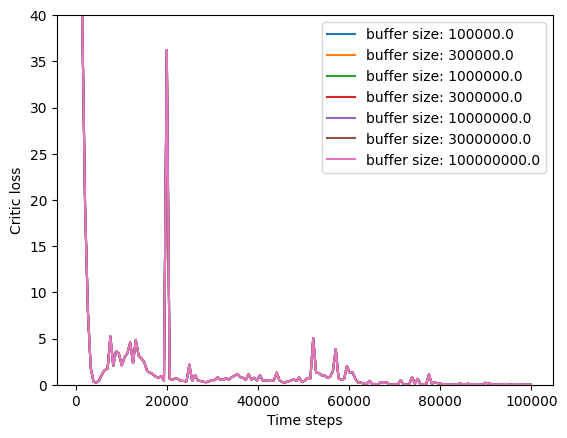

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

i = 17
for lr in [1e5, 3e5, 1e6, 3e6, 1e7, 3e7, 1e8]:
    df = pd.read_csv(f"../graphs/DDPG_{i}.csv")
    plt.plot(df['Step'], df['Value'], label=f"buffer size: {lr}")
    i+=1
plt.ylim(0, 40)
plt.ylabel('Critic loss')
plt.xlabel('Time steps')
plt.legend()
plt.show()

In [3]:
from stable_baselines3.common.noise import NormalActionNoise
from stable_baselines3.common.utils import LinearSchedule

for i in [256, 1000, 5000, 10000, 50000, 100000]:
    model = DDPG("MlpPolicy", envs, verbose=1, tensorboard_log="../logs/ddpg", seed=42, device='cuda', learning_rate=LinearSchedule(start=3e-3, end=3e-6, end_fraction=1.0), action_noise=NormalActionNoise([0, 0, 0], [0.1, 0.1, 0.1]), buffer_size=int(1e6), learning_starts=i)
    model.learn(total_timesteps=100_000, log_interval=10)
    model.save(f"../models/ddpg_ls{i}_100_000")

Using cuda device
Logging to ../logs/ddpg/DDPG_24
---------------------------------
| time/              |          |
|    episodes        | 10       |
|    fps             | 988      |
|    time_elapsed    | 0        |
|    total_timesteps | 885      |
| train/             |          |
|    actor_loss      | -137     |
|    critic_loss     | 147      |
|    learning_rate   | 0.00297  |
|    n_updates       | 125      |
---------------------------------
---------------------------------
| time/              |          |
|    episodes        | 20       |
|    fps             | 1019     |
|    time_elapsed    | 1        |
|    total_timesteps | 1500     |
| train/             |          |
|    actor_loss      | -137     |
|    critic_loss     | 114      |
|    learning_rate   | 0.00296  |
|    n_updates       | 248      |
---------------------------------
---------------------------------
| time/              |          |
|    episodes        | 30       |
|    fps             | 1031     

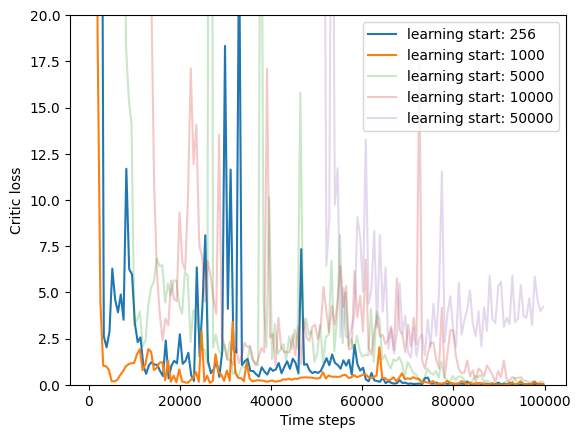

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

i = 24
for lr in [256, 1000, 5000, 10000, 50000]:
    df = pd.read_csv(f"../graphs/DDPG_{i}.csv")
    if i == 24 or i == 25:
        a = 1.0
    else:
        a = 0.25
    plt.plot(df['Step'], df['Value'], label=f"learning start: {lr}", alpha=a)
    i+=1
plt.ylim(0, 20)
plt.ylabel('Critic loss')
plt.xlabel('Time steps')
plt.legend()
plt.show()

In [6]:
from stable_baselines3.common.noise import NormalActionNoise
from stable_baselines3.common.utils import LinearSchedule

for i in [0, 32, 64, 128, 192, 512]:
    model = DDPG("MlpPolicy", envs, verbose=1, tensorboard_log="../logs/ddpg", seed=42, device='cuda', learning_rate=LinearSchedule(start=3e-3, end=3e-6, end_fraction=1.0), action_noise=NormalActionNoise([0, 0, 0], [0.1, 0.1, 0.1]), buffer_size=int(1e6), learning_starts=i)
    model.learn(total_timesteps=100_000, log_interval=10)
    model.save(f"../models/ddpg_ls{i}_100_000")

Using cuda device
Logging to ../logs/ddpg/DDPG_30
---------------------------------
| time/              |          |
|    episodes        | 10       |
|    fps             | 1105     |
|    time_elapsed    | 0        |
|    total_timesteps | 620      |
| train/             |          |
|    actor_loss      | -154     |
|    critic_loss     | 209      |
|    learning_rate   | 0.00298  |
|    n_updates       | 123      |
---------------------------------
---------------------------------
| time/              |          |
|    episodes        | 20       |
|    fps             | 1094     |
|    time_elapsed    | 1        |
|    total_timesteps | 1240     |
| train/             |          |
|    actor_loss      | -148     |
|    critic_loss     | 125      |
|    learning_rate   | 0.00296  |
|    n_updates       | 247      |
---------------------------------
---------------------------------
| time/              |          |
|    episodes        | 30       |
|    fps             | 1094     

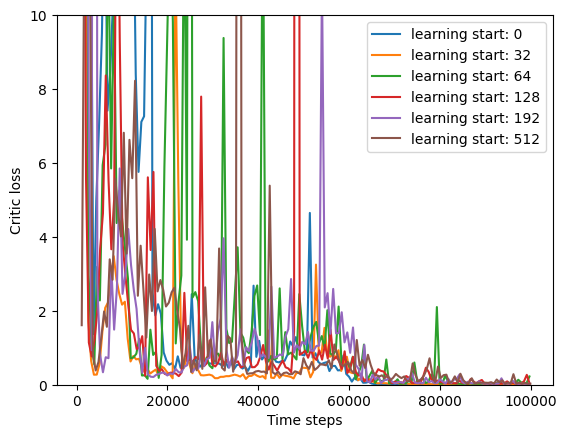

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

i = 30
for lr in [0, 32, 64, 128, 192, 512]:
    df = pd.read_csv(f"../graphs/DDPG_{i}.csv")
    plt.plot(df['Step'], df['Value'], label=f"learning start: {lr}")
    i+=1
plt.ylim(0, 10)
plt.ylabel('Critic loss')
plt.xlabel('Time steps')
plt.legend()
plt.show()

In [17]:
model = DDPG("MlpPolicy", envs, verbose=1, tensorboard_log="../logs/ddpg", seed=42, device='cuda', learning_rate=LinearSchedule(start=3e-3, end=3e-6, end_fraction=1.0), action_noise=NormalActionNoise([0, 0, 0], [0.5, 0.5, 0.5]), buffer_size=int(1e7), learning_starts=512)
model.learn(total_timesteps=1_000_000, log_interval=10)
model.save(f"../models/ddpg_1_000_000")

Using cuda device
Logging to ../logs/ddpg/DDPG_38
---------------------------------
| time/              |          |
|    episodes        | 10       |
|    fps             | 1727     |
|    time_elapsed    | 0        |
|    total_timesteps | 1075     |
| train/             |          |
|    actor_loss      | -109     |
|    critic_loss     | 40.2     |
|    learning_rate   | 0.003    |
|    n_updates       | 112      |
---------------------------------
---------------------------------
| time/              |          |
|    episodes        | 20       |
|    fps             | 1395     |
|    time_elapsed    | 1        |
|    total_timesteps | 1675     |
| train/             |          |
|    actor_loss      | -124     |
|    critic_loss     | 75.2     |
|    learning_rate   | 0.00299  |
|    n_updates       | 232      |
---------------------------------
---------------------------------
| time/              |          |
|    episodes        | 30       |
|    fps             | 1294     

In [ ]:
model = DDPG("MlpPolicy", envs, verbose=1, tensorboard_log="../logs/ddpg", seed=42, device='cuda', learning_rate=LinearSchedule(start=3e-3, end=3e-6, end_fraction=1.0), action_noise=NormalActionNoise([0, 0, 0], [0.05, 0.05, 0.05]), buffer_size=int(1e3), learning_starts=256)
model.learn(total_timesteps=1_000_000, log_interval=100)
model.save(f"../models/ddpg_1_000_000")

Using cuda device
Logging to ../logs/ddpg/DDPG_40


---------------------------------
| time/              |          |
|    episodes        | 100      |
|    fps             | 1104     |
|    time_elapsed    | 5        |
|    total_timesteps | 6425     |
| train/             |          |
|    actor_loss      | -104     |
|    critic_loss     | 0.981    |
|    learning_rate   | 0.003    |
|    n_updates       | 1233     |
---------------------------------
---------------------------------
| time/              |          |
|    episodes        | 200      |
|    fps             | 1095     |
|    time_elapsed    | 11       |
|    total_timesteps | 12600    |
| train/             |          |
|    actor_loss      | -90.2    |
|    critic_loss     | 1.99     |
|    learning_rate   | 0.003    |
|    n_updates       | 2468     |
---------------------------------
---------------------------------
| time/              |          |
|    episodes        | 300      |
|    fps             | 1080     |
|    time_elapsed    | 17       |
|    total_tim

KeyboardInterrupt: 

In [ ]:
import numpy as np
class MinMaxObservationWrapper(gym.ObservationWrapper):
    def __init__(self, env):
        super().__init__(env)

    def observation(self, obs):
        # Normalize to [0, 1]
        norm = (obs - self.observation_space.low) / (self.observation_space.high - self.observation_space.low)
        
        # Clip to ensure no out-of-bounds values (FlightGear can sometimes spit out anomalies)
        return np.clip(norm, 0, 1)

In [13]:
from stable_baselines3.common.noise import NormalActionNoise
from stable_baselines3.common.utils import LinearSchedule

envs = MinMaxObservationWrapper(gym.make("JSBSim-HeadingControlTask-Cessna172P-Shaping.STANDARD-NoFG-v0"))
model = DDPG("MlpPolicy", envs, verbose=1, tensorboard_log="../logs/ddpg", seed=42, device='cuda', learning_rate=LinearSchedule(start=3e-3, end=3e-6, end_fraction=1.0), action_noise=NormalActionNoise([0, 0, 0], [0.05, 0.05, 0.05]), buffer_size=int(1e6), learning_starts=100)
model.learn(total_timesteps=100_000, log_interval=100)
model.save(f"../models/ddpg_norm_100_000")

Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


     JSBSim Flight Dynamics Model v1.2.4 Feb  7 2026 11:12:49
            [JSBSim-ML v2.0]

JSBSim startup beginning ...

Logging to ../logs/ddpg/DDPG_43
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 43       |
|    ep_rew_mean     | 25.9     |
| time/              |          |
|    episodes        | 100      |
|    fps             | 306      |
|    time_elapsed    | 14       |
|    total_timesteps | 4301     |
| train/             |          |
|    actor_loss      | -7.78    |
|    critic_loss     | 0.0334   |
|    learning_rate   | 0.00287  |
|    n_updates       | 4200     |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 42       |
|    ep_rew_mean     | 25.8     |
| time/              |          |
|    episodes        | 200      |
|    fps             | 302      |
|

In [17]:
from stable_baselines3.common.noise import NormalActionNoise
from stable_baselines3.common.utils import LinearSchedule

envs = MinMaxObservationWrapper(gym.make("JSBSim-HeadingControlTask-Cessna172P-Shaping.STANDARD-NoFG-v0"))
model = DDPG("MlpPolicy", envs, verbose=1, tensorboard_log="../logs/ddpg", seed=42, device='cuda', learning_rate=LinearSchedule(start=3e-3, end=3e-7, end_fraction=1.0), action_noise=NormalActionNoise([0, 0, 0], [0.05, 0.05, 0.05]), buffer_size=int(1e6), learning_starts=100)
model.learn(total_timesteps=1_000_000, log_interval=100)
model.save(f"../models/ddpg_norm_1_000_000")

Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


     JSBSim Flight Dynamics Model v1.2.4 Feb  7 2026 11:12:49
            [JSBSim-ML v2.0]

JSBSim startup beginning ...

Logging to ../logs/ddpg/DDPG_47
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 43       |
|    ep_rew_mean     | 25.9     |
| time/              |          |
|    episodes        | 100      |
|    fps             | 318      |
|    time_elapsed    | 13       |
|    total_timesteps | 4301     |
| train/             |          |
|    actor_loss      | -7.76    |
|    critic_loss     | 0.0291   |
|    learning_rate   | 0.00299  |
|    n_updates       | 4200     |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 42       |
|    ep_rew_mean     | 25.8     |
| time/              |          |
|    episodes        | 200      |
|    fps             | 303      |
|

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


     JSBSim Flight Dynamics Model v1.2.4 Feb  7 2026 11:12:49
            [JSBSim-ML v2.0]

JSBSim startup beginning ...



/home/ondrej/Desktop/knn/.venv/lib/python3.13/site-packages/gymnasium/utils/passive_env_checker.py:334: UserWarning: WARN: No render fps was declared in the environment (env.metadata['render_fps'] is None or not defined), rendering may occur at inconsistent fps.
  logger.warn(


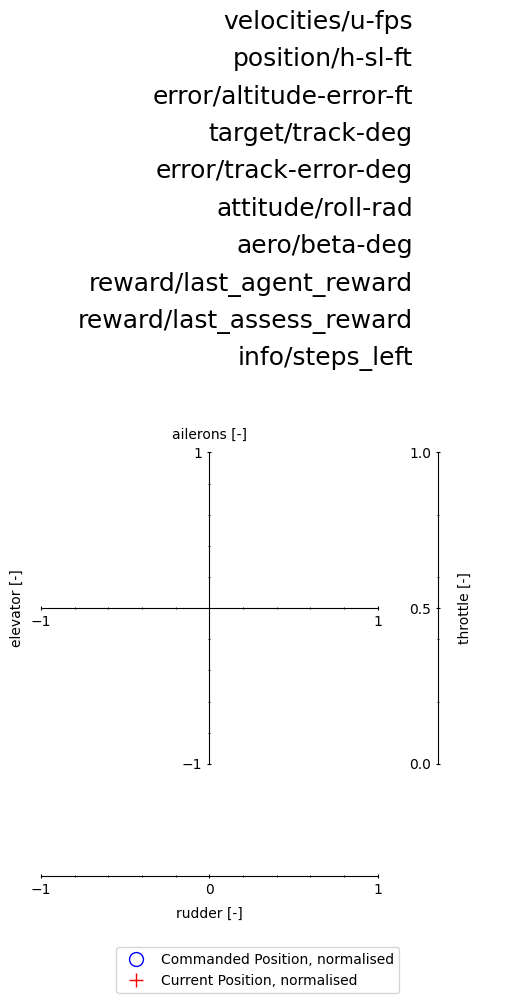

Socket error in Send - UDP data sending: Connection refused
Socket error in Send - UDP data sending: Connection refused
Socket error in Send - UDP data sending: Connection refused
Socket error in Send - UDP data sending: Connection refused
Socket error in Send - UDP data sending: Connection refused
Socket error in Send - UDP data sending: Connection refused
Socket error in Send - UDP data sending: Connection refused
Socket error in Send - UDP data sending: Connection refused
Socket error in Send - UDP data sending: Connection refused
Socket error in Send - UDP data sending: Connection refused
Socket error in Send - UDP data sending: Connection refused
Socket error in Send - UDP data sending: Connection refused
Socket error in Send - UDP data sending: Connection refused
Socket error in Send - UDP data sending: Connection refused
Socket error in Send - UDP data sending: Connection refused
Socket error in Send - UDP data sending: Connection refused
Socket error in Send - UDP data sending:

KeyboardInterrupt: 

In [18]:
# visualise
base_env = gym.make("JSBSim-HeadingControlTask-Cessna172P-Shaping.STANDARD-FG-v0")
model = DDPG.load("../models/ddpg_norm_1_000_000", env=base_env)
vec_env = model.get_env()
single_env = vec_env.envs[0]
obs, info = single_env.reset()

for episode in range(100000):
    action, _state = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = single_env.step(action)
    done = terminated or truncated
    single_env.render()
    if done:
        obs, info = single_env.reset()

base_env.close()